# Exercise 1

**Build a Random Forest model to classify COVID-19 severity**

Using the training cohort provided in Supplementary Table 3, build a Random Forest classification model similar to the one in the publication to distinguish between non-Severe and Severe COVID-19 patients.

Report the following performance metrics from cross-validation:

-   Confusion matrix
-   Accuracy
-   ROC curve and AUC. 

How well does the Random Forest model separate non-Severe from Severe patients based on proteomic profiles?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_excel("1-s2.0-S0092867420306279-mmc3.xlsx", sheet_name="Prot_and_meta_matrix")
patient_data = pd.read_excel('1-s2.0-S0092867420306279-mmc1.xlsx', sheet_name='Clinical_information')

## Loading data and preprocessing 


In [2]:
labels = patient_data[["Group d"]].set_index(patient_data["Patient ID a"])
print("Diferent labels: " + str(labels.nunique()))

Diferent labels: Group d    4
dtype: int64


There are 4 diferent labels in the dataset, they will be merged after cleaning

### Pivot the labels dataframe to have patient IDs as index and labels as column

In [3]:
features =  data.loc[1:, "Proteins/Metabolites"].tolist()
gene_symbols = data.loc[1:, "Gene Symbol"].tolist()
zipped_prots = pd.DataFrame(list(zip(features, gene_symbols)), columns=["Protein/Genes", "Gene Symbol"])
patients = data.loc[0].drop(["Proteins/Metabolites", "Gene Symbol"]).tolist()
X = (data.drop(columns=["Proteins/Metabolites", "Gene Symbol"]).iloc[1:].T)
X = X.apply(pd.to_numeric, errors="coerce")
X.columns = features
X.index = patients  
X = X.join(labels)


## Cleaning the dataset
Removing features based on the missing values

### Dropping columns and rows
### Missng values in labels
Removing the rows that doesn't have a label assigned

In [4]:
### Duplicate indexes
assert X.index.is_unique, "Duplicate patient IDs found"

### Missng values in labels
X = X.drop(index=X[X["Group d"].isna()].index.to_list())

### Columns that misses all values
X = X.dropna(axis=1, how="all")

### Columns that have NA values

In [5]:
print("There is: ", X.isna().any()[lambda x: x].value_counts()[True], " columns with NA values")

There is:  410  columns with NA values


For this part, we will remove columns that have more than 20% of missing values, the rest of missing values will be imputed later.

In [6]:
treshold = int(X.shape[0] * 0.80)
X = X.dropna(axis=1, thresh=treshold)
X.isna().any()[lambda x: x].value_counts();

### Inputing values with the mean of the column
Filling the missing values with the mean of the column

In [7]:
X = X.fillna(X.mean())

## Random Forest Pipeline
### Building a Random Forest model and ussing cross validation to evaluate it
Since we don't have enough data to have a separated test set, we will use cross validation to evaluate the model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

y = X["Group d"]
x = X.drop(columns=["Group d"]) 
scaler = StandardScaler(with_std= True)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
x = scaler.fit_transform(x)

## Cross-validation scores



In [9]:
cross_val_scores = cross_val_score(rf, x, y, cv=5)
print("Cross-validation scores:", cross_val_scores)
print("Mean cross-validation score:", np.mean(cross_val_scores))
print("Best model parameter (n_estimators):", rf.n_estimators)

Cross-validation scores: [0.85714286 1.         0.83333333 0.83333333 0.66666667]
Mean cross-validation score: 0.8380952380952381
Best model parameter (n_estimators): 100


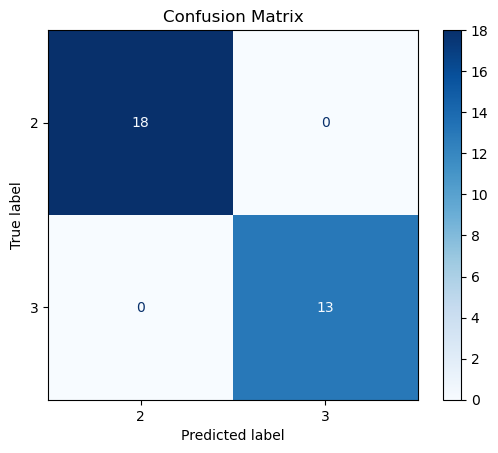

In [10]:
rf.fit(x, y)
y_pred = rf.predict(x)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Visualization of the results

In [11]:
print("\nClassification Report:\n", classification_report(y, y_pred))


Classification Report:
               precision    recall  f1-score   support

           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Conclusion

 The model is able to separate non-Severe from Severe patients based on proteomic profiles with a very high accuracy, but this is probably due to overfitting, since the dataset is really small and the model is really powerful.



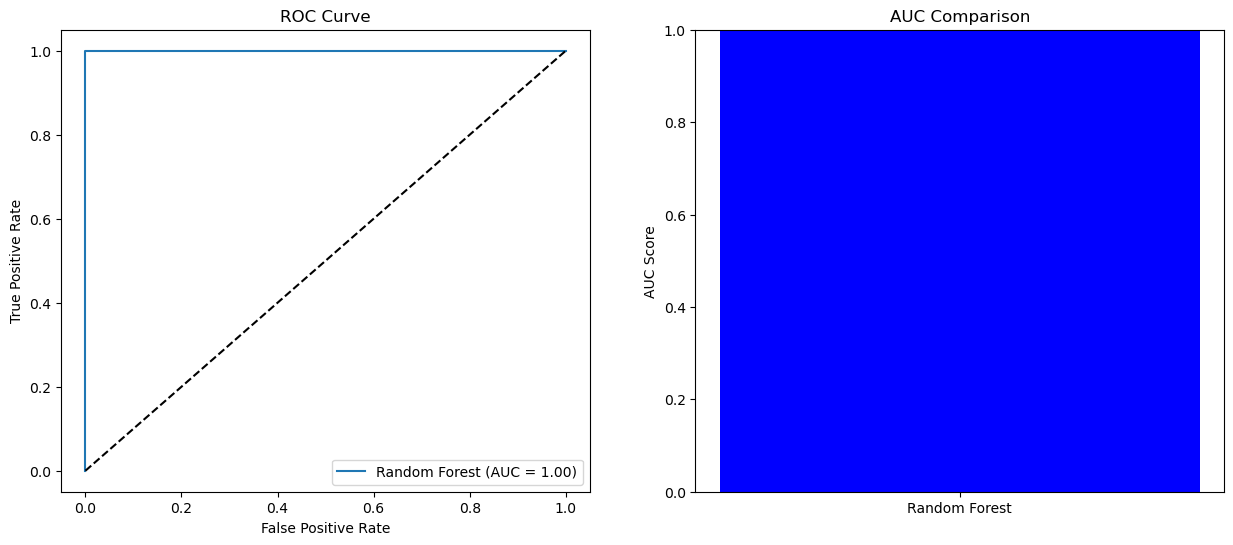

In [12]:
from sklearn.metrics import roc_curve, auc
y_pred_rf = rf.predict_proba(x)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y, y_pred_rf, pos_label=3)
roc_auc_rf = auc(fpr_rf, tpr_rf)


fig,ax = plt.subplots(1,2, figsize=(15,6))
ax[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc='lower right')
ax[1].bar(['Random Forest'], [roc_auc_rf], color='blue')
ax[1].set_ylim(0, 1)
ax[1].set_title('AUC Comparison')
ax[1].set_ylabel('AUC Score')
plt.show()

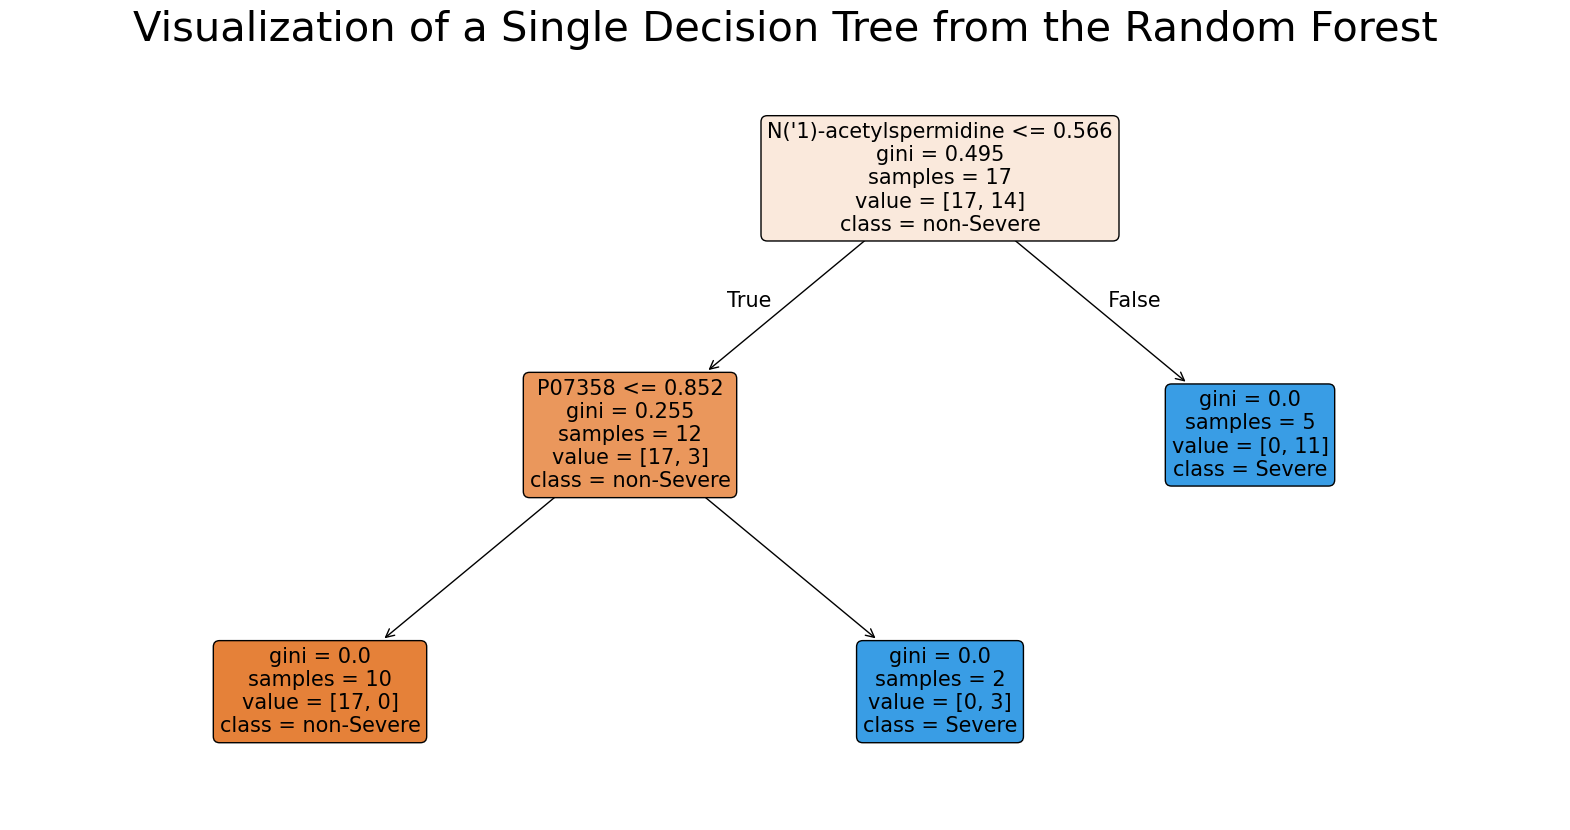

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = rf.estimators_[0]
dict_columns = {0: "Healthy", 1: "non-COVID-19", 2: "non-Severe", 3: "Severe"}
class_names = [str(i) for i in rf.classes_]
class_names = [dict_columns[int(i)] for i in class_names]
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, class_names=class_names, rounded=True, feature_names=X.columns, fontsize=15)
plt.title("Visualization of a Single Decision Tree from the Random Forest", fontsize=30)
plt.show()

# Exercise 2

**Identify and interpret the most important features**

Using the trained Random Forest model from Exercise 1, identify the 25 most important protein features contributing to the classification. Disccus their biological relevance.

Compare your selected features to the proteins reported by the authors in Supplementary Table 5.

## Feature importance from the Random Forest model

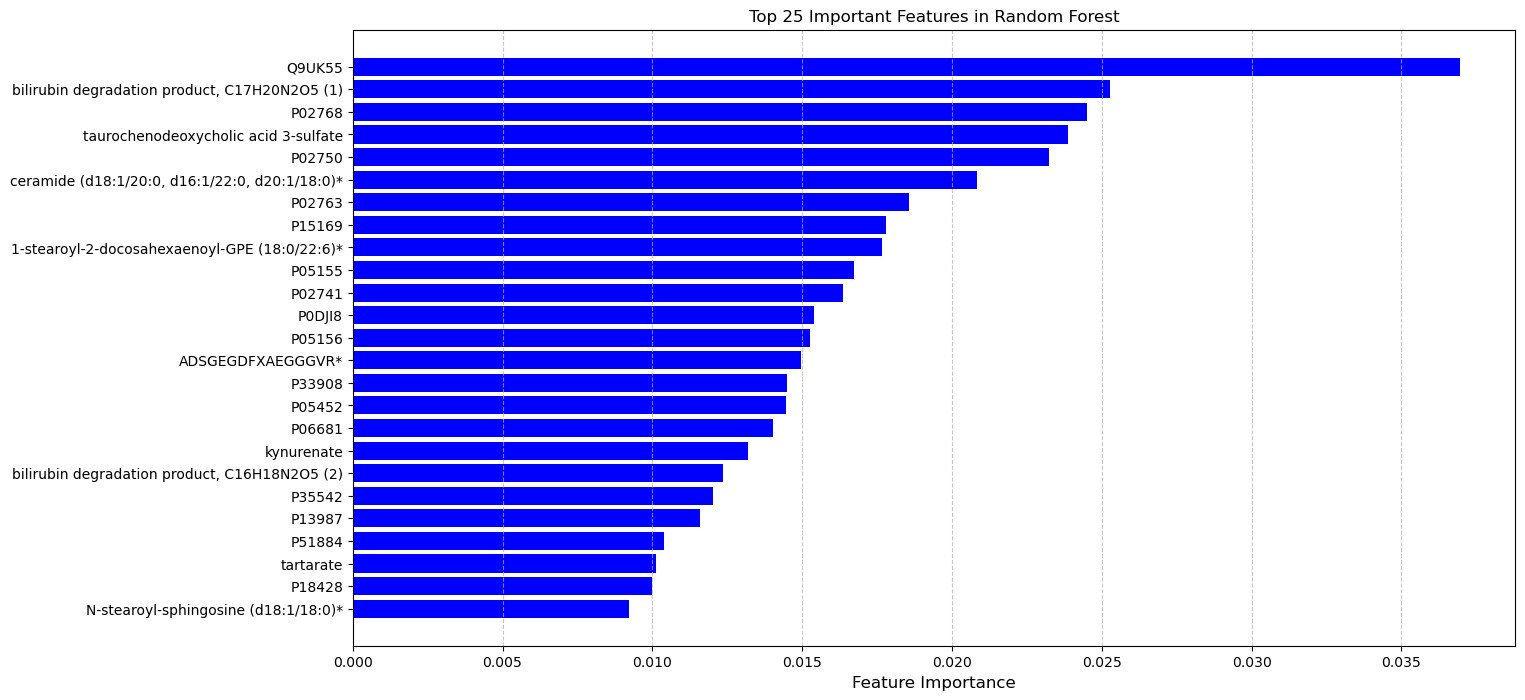

In [14]:
rf_features = [[index, value] for index, value in enumerate(rf.feature_importances_)]
rf_features.sort(key=lambda x: x[1], reverse=True)
rf_features = pd.DataFrame(rf_features[:25], columns=['index', 'importance'])
rf_features['feature'] = rf_features['index'].apply(lambda x: X.columns[x])
rf_features = rf_features.join(zipped_prots.set_index("Protein/Genes"), on="feature")
rf_features = rf_features.sort_values(by='importance', ascending=True)
plt.figure(figsize=(15, 8))
plt.barh(rf_features['feature'], rf_features['importance'], color='blue')
plt.xlabel('Feature Importance', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title('Top 25 Important Features in Random Forest')
plt.show()

## Comparison of the most important features with the ones reported by the authors

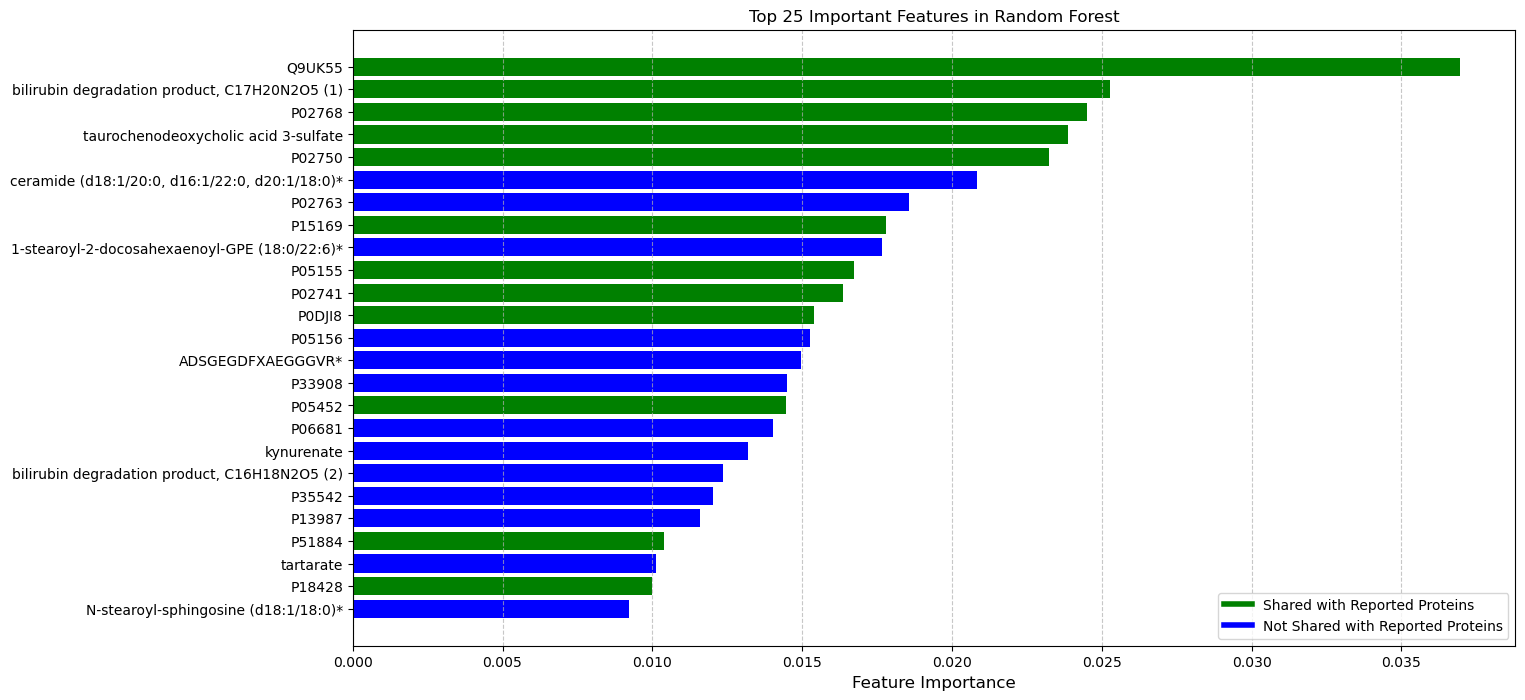

In [15]:
table_5 = pd.read_excel("1-s2.0-S0092867420306279-mmc5.xlsx", sheet_name="Prot_and_meta_matrix")
reported_proteins = table_5["Proteins/Metabolites"].dropna().tolist()
shared_proteins = set(rf_features.feature.tolist()).intersection(set(reported_proteins))
rf_features["Shared"] = rf_features["feature"].isin(shared_proteins)
rf_features = rf_features.sort_values(by='importance', ascending=True)
plt.figure(figsize=(15, 8))
plt.barh(rf_features['feature'], rf_features['importance'], color= rf_features['Shared'].map({True: 'green', False: 'blue'}))
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 25 Important Features in Random Forest')
plt.legend(handles=[plt.Line2D([0], [0], color='green', lw=4, label='Shared with Reported Proteins'),
                    plt.Line2D([0], [0], color='blue', lw=4, label='Not Shared with Reported Proteins')])
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Biological relevance of the shared features


The proteins and metabolites identified as most important by the Random Forest Classifier are closely related to both primary and secondary immune responses. This was expected, as SARS-CoV-2 infection naturally triggers an immune response. Several of the highlighted proteins are associated with the complement system, inflammatory pathways, and other immune-related mechanisms.
Therefore, we demonstrate that our ML approach performs correctly, as it successfully identifies proteins that clearly distinguish between non-severe patients (characterized by lower levels of inflammation) and severe patients.

# Exercise 3

**External prediction on an independent test cohort**

Using the final Random Forest model trained on the full training cohort, predict disease severity for patients in the independent test cohort provided in Supplementary Table 4.

Your task is to:

-   Apply the trained model to the test cohort.  
-   Obtain predicted probabilities of Severe disease for each patient.  
-   Assign predicted class labels based on these probabilities.  
-   Compare predictions to the true clinical labels.  


How does the model perform on the independent test cohort?

## Loading Table 4 and preprocessing

In [16]:
table_4 = pd.read_excel("1-s2.0-S0092867420306279-mmc4.xlsx", sheet_name="Prot_and_meta_matrix")

In [17]:
predict_columns = table_4.loc[1:, "Proteins/Metabolites"].tolist()
predict_index = table_4.loc[0].drop(["Proteins/Metabolites", "Gene Symbol"]).tolist()
X_test = (table_4.drop(columns=["Proteins/Metabolites", "Gene Symbol"]).iloc[1:].T)
X_test = X_test.apply(pd.to_numeric, errors="coerce")
X_test.columns = predict_columns
X_test.index = predict_index
X_test = X_test.fillna(X_test.mean())
shared_columns = X.columns.intersection(X_test.columns)
X_test = X_test[shared_columns]

## Problem:
Thy don't share the same features so we have to train another model.

In [18]:
print("Features in the training set:", X.shape[1])
print("Features in the test set:", X_test.shape[1])

Features in the training set: 1287
Features in the test set: 1275


### Solving this by training the model only with the shared features:

In [19]:
X_train = X.drop(columns=["Group d"])[shared_columns]
y_train = X["Group d"]
X_test = X_test[shared_columns]
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (31, 1275)
Test set shape: (10, 1275)


In [20]:
scaler = StandardScaler()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
x = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

### Training the model with the shared features and evaluating

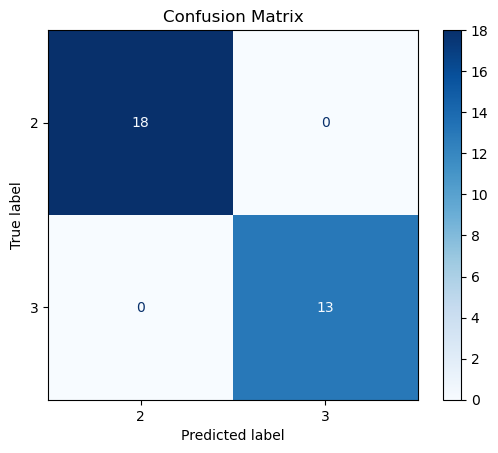

In [21]:
rf.fit(x, y_train)
y_pred = rf.predict(x)
cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [22]:
print("\nClassification Report:\n", classification_report(y_train, y_pred))


Classification Report:
               precision    recall  f1-score   support

           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        13

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31





## Predictions on the test set

### Classification report

In [23]:
predictions = rf.predict(x_test)
true_labels = labels.loc[X_test.index, "Group d"]
print("\nClassification Report:\n", classification_report(true_labels, predictions))
predictions_proba = rf.predict_proba(x_test)
predictions_proba_only = [i[0] for i in predictions_proba]


Classification Report:
               precision    recall  f1-score   support

           2       1.00      0.83      0.91         6
           3       0.80      1.00      0.89         4

    accuracy                           0.90        10
   macro avg       0.90      0.92      0.90        10
weighted avg       0.92      0.90      0.90        10



## Model Validation on test set

In [24]:
test_data = pd.DataFrame(index = X_test.index)
dict_columns = {0: "Healthy", 1: "non-COVID-19", 2: "non-Severe", 3: "Severe"}

test_data["Predicted. label"] = [dict_columns[int(i)] for i in predictions]
test_data["True label"] = labels.loc[X_test.index, "Group d"].map(dict_columns)
test_data['Predicted probability to be non-severe'] = predictions_proba_only
test_data


,Predicted. label,True label,Predicted probability to be non-severe
XG20,non-Severe,non-Severe,0.79
XG21,non-Severe,non-Severe,0.60
XG22,non-Severe,non-Severe,0.50
XG44,Severe,Severe,0.19
XG43,Severe,Severe,0.27
XG23,non-Severe,non-Severe,0.81
XG24,non-Severe,non-Severe,0.87
XG25,Severe,non-Severe,0.34
XG46,Severe,Severe,0.38
XG45,Severe,Severe,0.37


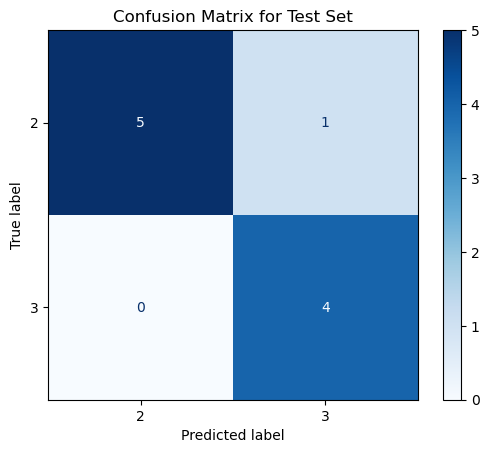

In [25]:
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Set")
plt.show()

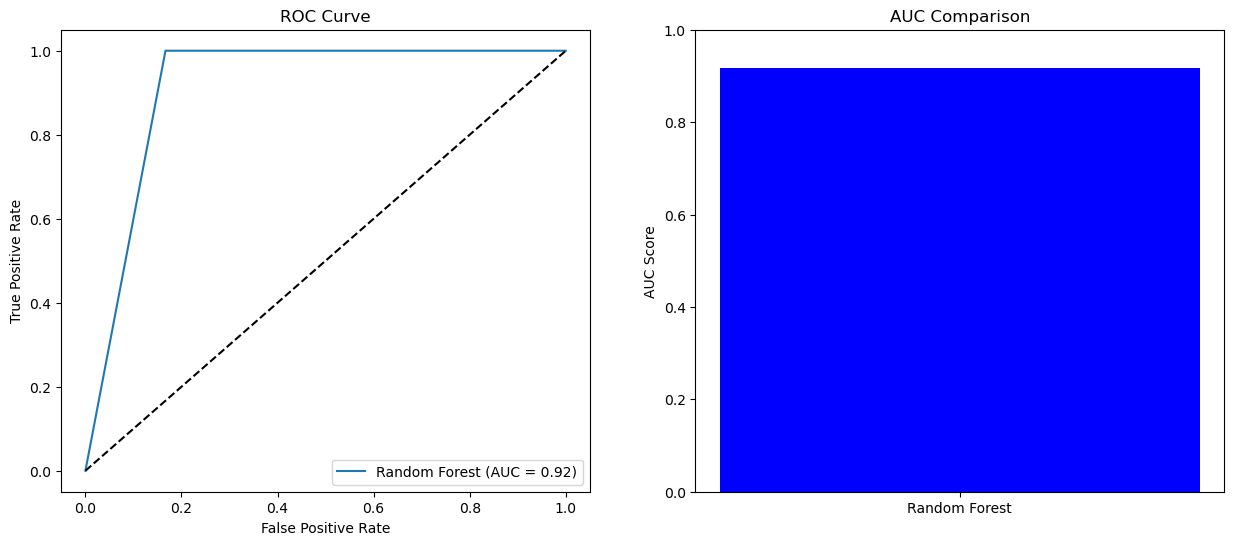

In [26]:
from sklearn.metrics import roc_curve, auc
y_pred_rf = rf.predict_proba(x_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(true_labels, predictions, pos_label=3)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fig,ax = plt.subplots(1,2, figsize=(15,6))
ax[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc='lower right')
ax[1].bar(['Random Forest'], [roc_auc_rf], color='blue')
ax[1].set_ylim(0, 1)
ax[1].set_title('AUC Comparison')
ax[1].set_ylabel('AUC Score')
plt.show()

As we see, almost all patients are well labeled with this second model. As said before, the problem with this ML approach is the poor dataset quality when refering to n patients. 31 samples is not enough to train properly a ML algorithm. Even though that, the model seems to work well, the question is if it is due to chance or not.